In [ ]:
# Config and imports
import os
import math
import random
from dataclasses import dataclass
from typing import List, Tuple, Dict, Any

import numpy as np
import pandas as pd
import networkx as nx
import osmnx as ox
from shapely.geometry import LineString, Point
import shapely
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster
from tqdm import tqdm

ox.settings.log_console=False
ox.settings.use_cache=True

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Study area and parameters
PLACE = "Vaud, Switzerland"  # change as needed
GRAPH_NETWORK_TYPE = "drive"
N_PAIRS = 50  # number of random origin-destination pairs
LATERAL_A_MAX = 0.1 * 9.81  # 0.1 g in m/s^2
STOP_PENALTY_S = 8.0  # seconds lost per stop (traffic light, roundabout entry)
MIN_EDGE_LENGTH_FOR_CURVATURE_M = 5.0  # filter too-short edges for curvature estimation

# Plot settings
sns.set_context("talk")
sns.set_style("whitegrid")


In [101]:
# Load and prepare OSM graph (robust)
print(f"Downloading graph for {PLACE} ...")
try:
    G = ox.graph_from_place(PLACE, network_type=GRAPH_NETWORK_TYPE, simplify=True)
except Exception as e:
    print(f"graph_from_place failed: {e}\nFalling back to geocode -> geometry")
    pgdf = ox.geocode_to_gdf(PLACE)
    # make geometries valid
    pgdf["geometry"] = pgdf["geometry"].apply(lambda g: shapely.make_valid(g) if g is not None else g)
    geoms = [g for g in pgdf.geometry.tolist() if g is not None and not g.is_empty]
    poly = None
    try:
        if len(geoms) == 1:
            poly = geoms[0]
        elif len(geoms) > 1:
            poly = shapely.union_all(geoms)
    except Exception as e2:
        print(f"union_all failed: {e2}")
    if poly is not None:
        G = ox.graph_from_polygon(poly, network_type=GRAPH_NETWORK_TYPE, simplify=True)
    else:
        minx, miny, maxx, maxy = pgdf.total_bounds
        # note: bbox args are north, south, east, west
        G = ox.graph_from_bbox(maxy, miny, maxx, minx, network_type=GRAPH_NETWORK_TYPE, simplify=True)
print("Done!")
G = ox.project_graph(G)

# Add speed/travel time attributes
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

# Basic stats
stats = ox.basic_stats(G)
print({k: stats[k] for k in ["edge_length_total", "street_length_total", "intersection_count"]})

# Build GeoDataFrames for edges and nodes
# edges_gdf = ox.utils_graph.graph_to_gdfs(G, nodes=False, fill_edge_geometry=True)
# nodes_gdf = ox.utils_graph.graph_to_gdfs(G, edges=False)
edges_gdf, nodes_gdf = ox.convert.graph_to_gdfs(G, fill_edge_geometry=True)
print(f"Edges: {len(edges_gdf)}, Nodes: {len(nodes_gdf)}")


Done!
{'edge_length_total': 13494251.444, 'street_length_total': 7119477.848, 'intersection_count': np.int64(20384)}
Edges: 25924, Nodes: 61019


# Tentative
### (ignore)

In [102]:
# Sample random node pairs within bounding polygon
# Filter to largest connected component for routing robustness
Gc = ox.utils_graph.get_largest_component(G, strongly=False)
Gc = nx.freeze(Gc)
print(f"Graph nodes: {len(G.nodes)}, edges: {len(G.edges)}")
print(f"Largest component nodes: {len(Gc.nodes)}, edges: {len(Gc.edges)}")
node_ids = list(Gc.nodes)

test_orig, test_dest = node_ids[0], node_ids[1]
try:
    test_route = ox.shortest_path(Gc, test_orig, test_dest, weight="length")
    print("Test route found:", test_route)
except Exception as e:
    print("Test route failed:", e)

pairs: List[Tuple[int, int]] = []
while len(pairs) < N_PAIRS:
    a, b = np.random.choice(node_ids, size=2, replace=False)
    if a == b:
        continue
    pairs.append((int(a), int(b)))

len(pairs), pairs[:3]


Graph nodes: 25924, edges: 61019
Largest component nodes: 25924, edges: 61019


C:\Users\arche\AppData\Local\Temp\ipykernel_23428\1943463790.py:3: FutureWarning: The `get_largest_component` function is deprecated and will be removed in the v2.0.0 release. Replace it with `truncate.largest_component` instead. See the OSMnx v2 migration guide: https://github.com/gboeing/osmnx/issues/1123
  Gc = ox.utils_graph.get_largest_component(G, strongly=False)


Test route found: [172276, 3783206756]


(50,
 [(1428764483, 879286324), (1698128198, 2371698873), (253256559, 395497775)])

In [103]:
# Curvature estimation and tilted travel time

def edge_curvature_radius_m(edge_geom: LineString) -> float:
    # Estimate radius from polyline by fitting circular arc on three points
    coords = list(edge_geom.coords)
    if len(coords) < 3:
        return float("inf")
    # pick start, mid, end
    p1 = np.array(coords[0]); p3 = np.array(coords[-1])
    mid_idx = len(coords)//2
    p2 = np.array(coords[mid_idx])
    # If points nearly colinear, return inf
    area2 = np.abs(np.cross(p2-p1, p3-p1))
    chord12 = np.linalg.norm(p2-p1)
    chord23 = np.linalg.norm(p3-p2)
    chord13 = np.linalg.norm(p3-p1)
    if area2 < 1e-6 or min(chord12, chord23, chord13) < 1e-3:
        return float("inf")
    # Circumradius formula: R = (a*b*c)/(4*Area)
    a, b, c = chord12, chord23, chord13
    s = (a+b+c)/2.0
    # Heron's area
    area = max(1e-9, math.sqrt(max(0.0, s*(s-a)*(s-b)*(s-c))))
    R = (a*b*c) / (4.0*area)
    return float(R)

In [104]:
# Compute curvature radius for each edge and average for curves only
curvature_radii = edges_gdf['geometry'].apply(edge_curvature_radius_m)

# Define a threshold: treat radii > 5000m as "straight" (adjust as needed)
curve_mask = (curvature_radii < 5000)

# Compute average curvature radius for curves only
average_curve_radius = curvature_radii[curve_mask].mean()

print(f"Average curvature radius (for curves): {average_curve_radius:.1f} meters")

Average curvature radius (for curves): nan meters


In [105]:
curvature_radii.describe()

c:\Users\arche\Documents\Neodrive\simtilt_env\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\arche\Documents\Neodrive\simtilt_env\Lib\site-packages\numpy\lib\_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


count    25924.0
mean         inf
std          NaN
min          inf
25%          NaN
50%          NaN
75%          NaN
max          inf
Name: geometry, dtype: float64

In [106]:
edges_gdf['geometry']

osmid
172276         POINT (321019.364 5153238.341)
3783206756     POINT (321203.064 5153211.684)
267469260      POINT (320923.204 5153278.939)
172284          POINT (322106.611 5152678.11)
265064219      POINT (322083.161 5152671.359)
                            ...              
13033184351    POINT (314327.135 5175697.348)
13033184359    POINT (314335.494 5175710.159)
13036424416    POINT (311933.737 5177177.138)
13089580027    POINT (316177.813 5161576.433)
13145014713    POINT (318968.891 5167897.979)
Name: geometry, Length: 25924, dtype: geometry

# Let's start again
### (ignore)

In [107]:
# Sample random node pairs within bounding polygon
# Filter to largest connected component for routing robustness
Gc = ox.utils_graph.get_largest_component(G, strongly=False)
Gc = nx.freeze(Gc)
print(f"Graph nodes: {len(G.nodes)}, edges: {len(G.edges)}")
print(f"Largest component nodes: {len(Gc.nodes)}, edges: {len(Gc.edges)}")
node_ids = list(Gc.nodes)

test_orig, test_dest = node_ids[0], node_ids[1]
try:
    test_route = ox.shortest_path(Gc, test_orig, test_dest, weight="length")
    print("Test route found:", test_route)
except Exception as e:
    print("Test route failed:", e)

pairs: List[Tuple[int, int]] = []
while len(pairs) < N_PAIRS:
    a, b = np.random.choice(node_ids, size=2, replace=False)
    if a == b:
        continue
    pairs.append((int(a), int(b)))

len(pairs), pairs[:3]

Graph nodes: 25924, edges: 61019
Largest component nodes: 25924, edges: 61019


C:\Users\arche\AppData\Local\Temp\ipykernel_23428\1997273902.py:3: FutureWarning: The `get_largest_component` function is deprecated and will be removed in the v2.0.0 release. Replace it with `truncate.largest_component` instead. See the OSMnx v2 migration guide: https://github.com/gboeing/osmnx/issues/1123
  Gc = ox.utils_graph.get_largest_component(G, strongly=False)


Test route found: [172276, 3783206756]


(50,
 [(936793416, 9180609411), (471491461, 290341867), (2128897131, 3540580253)])

In [108]:
# Compute routes (shortest by distance)
# Precompute edge lengths from graph projection (meters)
for u, v, k, data in Gc.edges(keys=True, data=True):
    if "length" not in data:
        if "geometry" in data and isinstance(data["geometry"], LineString):
            data["length"] = data["geometry"].length
        else:
            # straight-line distance between projected node coords
            xy_u = (Gc.nodes[u]["x"], Gc.nodes[u]["y"]) 
            xy_v = (Gc.nodes[v]["x"], Gc.nodes[v]["y"]) 
            data["length"] = math.hypot(xy_u[0] - xy_v[0], xy_u[1] - xy_v[1])

routes_edges: List[List[Tuple[int,int,int]]] = []
routes_nodes: List[List[int]] = []
route_lengths_m: List[float] = []
kept_pairs: List[Tuple[int,int]] = []

In [109]:
for (orig, dest) in tqdm(pairs, desc="Routing by distance"):
    try:
        route_nodes = ox.shortest_path(Gc, orig, dest, weight="length")  # node list
        print(f"Route found: {orig} -> {dest}")
        print(route_nodes)
        total_len = sum(Gc[route_nodes[i]][route_nodes[i+1]][0]["length"] for i in range(len(route_nodes)-1))
        route_lengths_m.append(float(total_len))
        kept_pairs.append((orig, dest))
    except Exception as e:
        print(f"Routing failed for {orig}->{dest}: {e}")
        continue

len(routes_edges), len(route_lengths_m)

Routing by distance:   4%|▍         | 2/50 [00:00<00:07,  6.63it/s]

Route found: 936793416 -> 9180609411
[936793416, 295170334, 243639709, 1604658119, 9306563296, 295182881, 295182893, 10091634804, 10091634808, 243075122, 229872699, 229945952, 296365503, 229939358, 229939347, 229922681, 296374899, 229977337, 229987367, 229977191, 229984163, 227192680, 3093104718, 9119715424, 1996572, 243507364, 243737871, 331278770, 331278768, 534845006, 243507457, 243508318, 2694229282, 3048981608, 441306105, 732507373, 3049004098, 430871026, 441306781, 243508233, 2943940820, 3088909797, 2943940798, 2510806860, 273929162, 9432754623, 3829978289, 3089338820, 3192346603, 697315836, 3089363160, 3089363151, 3089338776, 442249972, 1437661639, 2647313003, 3027187742, 2647312919, 3017608394, 2647312878, 2647312863, 2647312885, 1478083522, 989988878, 2639724278, 3017693564, 2647312780, 9180609411]
Route found: 471491461 -> 290341867
[471491461, 471493261, 471493260, 471338426, 471888710, 1446081035, 1446185478, 471888657, 471556576, 364739944, 1446185398, 471556502, 142016229

Routing by distance:   8%|▊         | 4/50 [00:00<00:07,  6.32it/s]

Route found: 2128897131 -> 3540580253
[2128897131, 292170253, 582627617, 286706991, 290660174, 341365570, 341365577, 341365564, 341365568, 341365547, 741479853, 571224225, 271323207, 341365533, 271323211, 253399655, 253399659, 602698267, 286706989, 602698295, 602698297, 602699327, 421804917, 253399847, 271324366, 35296878, 253303084, 564208341, 35295145, 564683515, 155053225, 35297474, 5234497233, 35297476, 421804906, 581203385, 614835308, 614835334, 581105474, 420770599, 581105480, 280671, 300396131, 561549828, 269580070, 288435911, 1041075496, 337933269, 337933293, 337933299, 3183594026, 3090790052, 3090790050, 3090790049, 504657, 7836769649, 7836769650, 1094605491, 266381324, 3781928850, 266381328, 172276, 3783206756, 276521477, 262930173, 264510648, 266197687, 265614661, 264512660, 264746367, 265590267, 265590251, 265590254, 265590256, 265590257, 265614441, 265614479, 265590260, 265614495, 265590262, 265614517, 1436761068, 1187313064, 1187313050, 268560389, 427959532, 268638247, 28

Routing by distance:  12%|█▏        | 6/50 [00:01<00:07,  5.88it/s]

...

Routing by distance:  98%|█████████▊| 49/50 [00:08<00:00,  5.52it/s]

Route found: 253079086 -> 11050023893
[253079086, 5329581346, 253079087, 5329581190, 5329581218, 5329581212, 5329581205, 253079126, 3276697074, 253078951, 313700328, 313700334, 4605580501, 333688239, 4605580517, 11461777380, 333688262, 4605580513, 5356971386, 5356971387, 278988199, 5346751643, 6720922110, 5346751649, 5356971119, 5356971329, 279309794, 279305905, 333677124, 321543977, 274813468, 274813458, 640359167, 4457815498, 333677156, 333677188, 327287775, 333677198, 8832765542, 1340329181, 5895632869, 5895632877, 5895637309, 5895637312, 275555662, 1221156349, 300396292, 300396293, 6518723778, 300396287, 286034349, 286036528, 286034342, 331227897, 286034340, 286034339, 331227864, 286034229, 291160317, 291160414, 7367367262, 291160400, 7108056106, 291160399, 291160477, 1673767610, 1673767513, 988573150, 1673767559, 319421843, 8929692957, 5072993360, 1865629515, 1865603396, 2817592846, 2807323861, 2807323863, 286043621, 286043555, 253634759, 286044442, 253635557, 436168992, 196461247

Routing by distance: 100%|██████████| 50/50 [00:09<00:00,  5.48it/s]

Route found: 603644059 -> 12194113547
[603644059, 3246851627, 9285993564, 1989860, 434309945, 290232303, 434309947, 244222997, 2296353092, 2392730050, 243508165, 319281972, 2382126418, 2382126402, 426936042, 426934726, 2434232866, 907106274, 951471573, 243508233, 2943940820, 563907745, 2943940799, 2943940764, 2943940754, 313636044, 3189436194, 2943940730, 2943940746, 11572466426, 3648487319, 3648487316, 11573433326, 11573433324, 11573433321, 387848235, 354077343, 313636037, 379589157, 9947377036, 9947377044, 512563761, 1487718198, 322202211, 322202203, 348370996, 290776908, 348370986, 259611771, 1891363259, 2278184821, 319830250, 259611722, 259611517, 2813088642, 4225707620, 4225707622, 3004354807, 8478587592, 259611521, 259611610, 259611688, 309949568, 278988629, 278988630, 278988670, 309734771, 278988727, 278988635, 309945040, 347656464, 278988589, 278988590, 8974603391, 8974603392, 278988556, 294685755, 1181321012, 1183364434, 1181321622, 294685741, 269615924, 269615927, 275559734, 

(0, 49)

In [110]:
import numpy as np

def curvature_radius_from_points(p1, p2, p3):
    # p1, p2, p3: (x, y) tuples
    a = np.linalg.norm(np.array(p2) - np.array(p1))
    b = np.linalg.norm(np.array(p3) - np.array(p2))
    c = np.linalg.norm(np.array(p3) - np.array(p1))
    s = (a + b + c) / 2.0
    area = max(1e-9, np.sqrt(max(0.0, s * (s - a) * (s - b) * (s - c))))
    if area < 1e-6:
        return float("inf")
    return (a * b * c) / (4.0 * area)

# Example: use a real route from your computed routes
# For demonstration, use the first valid route from your earlier code
path = route_nodes

coords = [ (Gc.nodes[n]['x'], Gc.nodes[n]['y']) for n in path ]

radii = []
for i in range(len(coords) - 2):
    r = curvature_radius_from_points(coords[i], coords[i+1], coords[i+2])
    radii.append(r)

# Now radii contains the curvature radius at each bend along the path
curve_radii = [r for r in radii if r < 5000]  # filter out straight segments
if curve_radii:
    average_curve_radius = np.mean(curve_radii)
    print(f"Average curvature radius along path: {average_curve_radius:.1f} meters")
else:
    print("No curves detected along this path.")

Average curvature radius along path: 872.7 meters


In [111]:
curve_radii

[np.float64(36.615772926833024),
 np.float64(39.776666772335034),
 np.float64(60.91648952802695),
 np.float64(955.7394624244058),
 np.float64(61.47892795900616),
 np.float64(1154.4589217063776),
 np.float64(4432.284465577295),
 np.float64(2982.6709504711043),
 np.float64(62.96923304162115),
 np.float64(73.85783745478771),
 np.float64(2129.3884925451434),
 np.float64(398.801810792315),
 np.float64(356.6244684479891),
 np.float64(187.1365722421553),
 np.float64(147.1976825786839),
 np.float64(851.4983008722323),
 np.float64(421.7488603652659),
 np.float64(747.4706554893568),
 np.float64(3984.559146582232),
 np.float64(1537.9159001778482),
 np.float64(1137.866522414642),
 np.float64(11.7962976649369),
 np.float64(55.98469378280955),
 np.float64(498.17925160064755),
 np.float64(680.5182422748878),
 np.float64(34.44934531780812),
 np.float64(13.117866476449661),
 np.float64(10.896347745275973),
 np.float64(56.773629632015606),
 np.float64(2132.507588467471),
 np.float64(598.5968498349586),


In [112]:
path

[603644059,
 3246851627,
 9285993564,
 1989860,
 434309945,
 290232303,
 434309947,
 244222997,
 2296353092,
 2392730050,
 243508165,
 319281972,
 2382126418,
 2382126402,
 426936042,
 426934726,
 2434232866,
 907106274,
 951471573,
 243508233,
 2943940820,
 563907745,
 2943940799,
 2943940764,
 2943940754,
 313636044,
 3189436194,
 2943940730,
 2943940746,
 11572466426,
 3648487319,
 3648487316,
 11573433326,
 11573433324,
 11573433321,
 387848235,
 354077343,
 313636037,
 379589157,
 9947377036,
 9947377044,
 512563761,
 1487718198,
 322202211,
 322202203,
 348370996,
 290776908,
 348370986,
 259611771,
 1891363259,
 2278184821,
 319830250,
 259611722,
 259611517,
 2813088642,
 4225707620,
 4225707622,
 3004354807,
 8478587592,
 259611521,
 259611610,
 259611688,
 309949568,
 278988629,
 278988630,
 278988670,
 309734771,
 278988727,
 278988635,
 309945040,
 347656464,
 278988589,
 278988590,
 8974603391,
 8974603392,
 278988556,
 294685755,
 1181321012,
 1183364434,
 1181321622,
 29

In [113]:
route_nodes

[603644059,
 3246851627,
 9285993564,
 1989860,
 434309945,
 290232303,
 434309947,
 244222997,
 2296353092,
 2392730050,
 243508165,
 319281972,
 2382126418,
 2382126402,
 426936042,
 426934726,
 2434232866,
 907106274,
 951471573,
 243508233,
 2943940820,
 563907745,
 2943940799,
 2943940764,
 2943940754,
 313636044,
 3189436194,
 2943940730,
 2943940746,
 11572466426,
 3648487319,
 3648487316,
 11573433326,
 11573433324,
 11573433321,
 387848235,
 354077343,
 313636037,
 379589157,
 9947377036,
 9947377044,
 512563761,
 1487718198,
 322202211,
 322202203,
 348370996,
 290776908,
 348370986,
 259611771,
 1891363259,
 2278184821,
 319830250,
 259611722,
 259611517,
 2813088642,
 4225707620,
 4225707622,
 3004354807,
 8478587592,
 259611521,
 259611610,
 259611688,
 309949568,
 278988629,
 278988630,
 278988670,
 309734771,
 278988727,
 278988635,
 309945040,
 347656464,
 278988589,
 278988590,
 8974603391,
 8974603392,
 278988556,
 294685755,
 1181321012,
 1183364434,
 1181321622,
 29

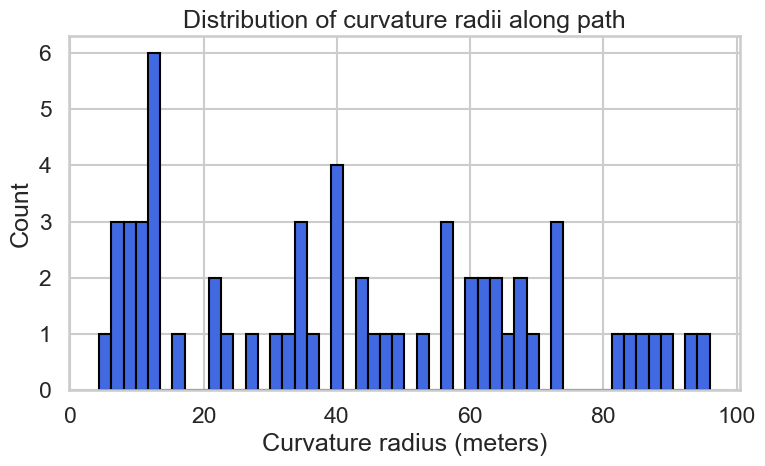

In [114]:
import matplotlib.pyplot as plt

# Only plot radii for actual curves (e.g., r < 5000)
curve_radii = [r for r in radii if r < 5000]

plt.figure(figsize=(8, 5))
x = [r for r in radii if r < 100]
plt.hist(x, bins=50, color='royalblue', edgecolor='black')
# plt.xscale('log')
plt.xlabel('Curvature radius (meters)')
plt.ylabel('Count')
plt.title('Distribution of curvature radii along path')
plt.tight_layout()
plt.show()

# Better calculation
So that straight lines add a smaller contribution and results are more interpretable

In [115]:
# New approach: Angle-based curvature contribution
# Instead of computing radius, we compute the angle between three points
# and use 180° - angle as the contribution (0 for straight lines, higher for curves)

def angle_between_vectors(v1, v2):
    """Compute angle between two vectors in degrees"""
    # Normalize vectors
    v1_norm = v1 / np.linalg.norm(v1)
    v2_norm = v2 / np.linalg.norm(v2)
    
    # Compute dot product and clamp to avoid numerical errors
    dot_product = np.clip(np.dot(v1_norm, v2_norm), -1.0, 1.0)
    
    # Convert to degrees
    angle_rad = np.arccos(dot_product)
    angle_deg = np.degrees(angle_rad)
    
    return angle_deg

def curvature_contribution_from_points(p1, p2, p3):
    """
    Compute curvature contribution using 180° - angle approach.
    For three points a, b, c in order, compute the angle at point b.
    Returns 180° - angle, so straight lines contribute ~0, curves contribute more.
    """
    p1, p2, p3 = np.array(p1), np.array(p2), np.array(p3)
    
    # Vectors from b to a and b to c
    v1 = p1 - p2  # vector from p2 to p1
    v2 = p3 - p2  # vector from p2 to p3
    
    # Check for degenerate cases (points too close)
    if np.linalg.norm(v1) < 1e-6 or np.linalg.norm(v2) < 1e-6:
        return 0.0
    
    # Compute angle between vectors
    angle = angle_between_vectors(v1, v2)
    
    # Return 180° - angle as contribution
    contribution = 180.0 - angle
    
    return contribution

# Test the new approach on the same route
print("Testing angle-based curvature contribution...")
print(f"Route has {len(route_nodes)} nodes")

# Get coordinates for the route
coords = [(Gc.nodes[n]['x'], Gc.nodes[n]['y']) for n in route_nodes]

# Compute curvature contributions using the new method
contributions = []
for i in range(len(coords) - 2):
    contrib = curvature_contribution_from_points(coords[i], coords[i+1], coords[i+2])
    contributions.append(contrib)

print(f"Computed {len(contributions)} curvature contributions")
print(f"Contribution range: {min(contributions):.2f}° to {max(contributions):.2f}°")
print(f"Average contribution: {np.mean(contributions):.2f}°")
print(f"Standard deviation: {np.std(contributions):.2f}°")


Testing angle-based curvature contribution...
Route has 251 nodes
Computed 249 curvature contributions
Contribution range: 0.01° to 154.93°
Average contribution: 28.79°
Standard deviation: 30.42°


In [116]:
# Compare old radius-based vs new angle-based approach
print("\n" + "="*60)
print("COMPARISON: Radius-based vs Angle-based approach")
print("="*60)

# Old approach: radius-based
print("\nOLD APPROACH (Radius-based):")
radii = []
for i in range(len(coords) - 2):
    r = curvature_radius_from_points(coords[i], coords[i+1], coords[i+2])
    radii.append(r)

# Filter out infinite radii (straight segments)
finite_radii = [r for r in radii if r != float('inf') and r < 5000]
print(f"Total segments: {len(radii)}")
print(f"Finite radii (curves only): {len(finite_radii)}")
print(f"Straight segments (infinite radius): {len(radii) - len(finite_radii)}")

if finite_radii:
    print(f"Average radius for curves: {np.mean(finite_radii):.1f} meters")
    print(f"Radius range: {min(finite_radii):.1f} to {max(finite_radii):.1f} meters")
else:
    print("No curves detected with radius approach!")

# New approach: angle-based
print(f"\nNEW APPROACH (Angle-based):")
print(f"Total segments: {len(contributions)}")
print(f"Average contribution: {np.mean(contributions):.2f}°")
print(f"Contribution range: {min(contributions):.2f}° to {max(contributions):.2f}°")

# Show some examples
print(f"\nFirst 10 contributions:")
for i in range(min(10, len(contributions))):
    print(f"  Segment {i+1}: {contributions[i]:.2f}°")

# Show segments with highest curvature
print(f"\nTop 5 most curved segments:")
sorted_indices = np.argsort(contributions)[::-1]
for i, idx in enumerate(sorted_indices[:5]):
    print(f"  #{i+1} (segment {idx+1}): {contributions[idx]:.2f}°")



COMPARISON: Radius-based vs Angle-based approach

OLD APPROACH (Radius-based):
Total segments: 249
Finite radii (curves only): 225
Straight segments (infinite radius): 24
Average radius for curves: 872.7 meters
Radius range: 4.3 to 4837.9 meters

NEW APPROACH (Angle-based):
Total segments: 249
Average contribution: 28.79°
Contribution range: 0.01° to 154.93°

First 10 contributions:
  Segment 1: 79.84°
  Segment 2: 63.34°
  Segment 3: 68.24°
  Segment 4: 5.68°
  Segment 5: 76.30°
  Segment 6: 4.23°
  Segment 7: 0.40°
  Segment 8: 10.83°
  Segment 9: 10.34°
  Segment 10: 14.25°

Top 5 most curved segments:
  #1 (segment 128): 154.93°
  #2 (segment 247): 152.66°
  #3 (segment 242): 149.90°
  #4 (segment 127): 147.52°
  #5 (segment 246): 141.16°


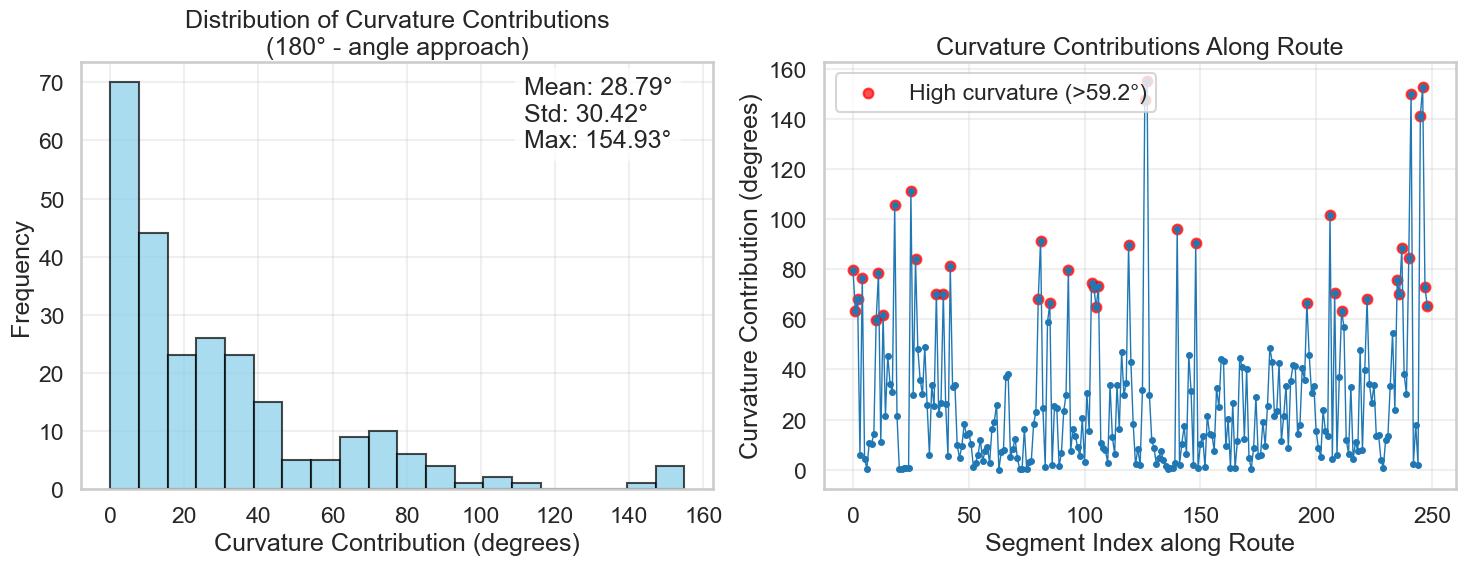


Segments with high curvature (>59.2°): 40
Percentage of high curvature segments: 16.1%


In [117]:
# Visualization of the new approach
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Distribution of curvature contributions
ax1.hist(contributions, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Curvature Contribution (degrees)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Curvature Contributions\n(180° - angle approach)')
ax1.grid(True, alpha=0.3)

# Add statistics text
ax1.text(0.7, 0.8, f'Mean: {np.mean(contributions):.2f}°\nStd: {np.std(contributions):.2f}°\nMax: {max(contributions):.2f}°', 
         transform=ax1.transAxes, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# Plot 2: Curvature contributions along the route
ax2.plot(range(len(contributions)), contributions, 'o-', markersize=4, linewidth=1)
ax2.set_xlabel('Segment Index along Route')
ax2.set_ylabel('Curvature Contribution (degrees)')
ax2.set_title('Curvature Contributions Along Route')
ax2.grid(True, alpha=0.3)

# Highlight segments with high curvature
high_curvature_threshold = np.mean(contributions) + np.std(contributions)
high_curvature_indices = [i for i, c in enumerate(contributions) if c > high_curvature_threshold]
ax2.scatter(high_curvature_indices, [contributions[i] for i in high_curvature_indices], 
           color='red', s=50, alpha=0.7, label=f'High curvature (>{high_curvature_threshold:.1f}°)')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nSegments with high curvature (>{high_curvature_threshold:.1f}°): {len(high_curvature_indices)}")
print(f"Percentage of high curvature segments: {len(high_curvature_indices)/len(contributions)*100:.1f}%")


In [118]:
# Function to compute average curvature for multiple routes using the new approach
def compute_route_curvature_contribution(route_nodes, graph):
    """
    Compute curvature contribution for a route using the angle-based approach.
    Returns the average contribution and individual contributions.
    """
    coords = [(graph.nodes[n]['x'], graph.nodes[n]['y']) for n in route_nodes]
    
    contributions = []
    for i in range(len(coords) - 2):
        contrib = curvature_contribution_from_points(coords[i], coords[i+1], coords[i+2])
        contributions.append(contrib)
    
    return np.mean(contributions), contributions

# Test on all available routes
print("Computing curvature contributions for all routes...")
print(f"Number of routes available: {len(kept_pairs)}")

route_curvature_means = []
route_curvature_details = []

for i, (orig, dest) in enumerate(kept_pairs):
    try:
        route_nodes = ox.shortest_path(Gc, orig, dest, weight="length")
        mean_contrib, contributions = compute_route_curvature_contribution(route_nodes, Gc)
        route_curvature_means.append(mean_contrib)
        route_curvature_details.append(contributions)
        
        if i < 3:  # Show details for first 3 routes
            print(f"\nRoute {i+1}: {orig} -> {dest}")
            print(f"  Length: {len(route_nodes)} nodes")
            print(f"  Average curvature contribution: {mean_contrib:.2f}°")
            print(f"  Contribution range: {min(contributions):.2f}° to {max(contributions):.2f}°")
    except Exception as e:
        print(f"Failed to compute route {i+1}: {e}")

print(f"\nOverall statistics across all routes:")
print(f"Number of successful routes: {len(route_curvature_means)}")
print(f"Average curvature contribution per route: {np.mean(route_curvature_means):.2f}°")
print(f"Standard deviation: {np.std(route_curvature_means):.2f}°")
print(f"Range: {min(route_curvature_means):.2f}° to {max(route_curvature_means):.2f}°")


Computing curvature contributions for all routes...
Number of routes available: 49

Route 1: 936793416 -> 9180609411
  Length: 68 nodes
  Average curvature contribution: 25.71°
  Contribution range: 0.18° to 134.76°

Route 2: 471491461 -> 290341867
  Length: 145 nodes
  Average curvature contribution: 21.31°
  Contribution range: 0.02° to 131.69°

Route 3: 2128897131 -> 3540580253
  Length: 396 nodes
  Average curvature contribution: 20.24°
  Contribution range: 0.01° to 123.32°

Overall statistics across all routes:
Number of successful routes: 49
Average curvature contribution per route: 24.79°
Standard deviation: 4.98°
Range: 17.24° to 44.65°


In [119]:
# Visualize a route on a map with curvature contributions
import folium
from folium.plugins import HeatMap
import matplotlib.colors as mcolors

# Select a route to visualize (let's use the first route)
route_idx = 0
orig, dest = kept_pairs[route_idx]
route_nodes = ox.shortest_path(Gc, orig, dest, weight="length")

print(f"Visualizing Route {route_idx + 1}: {orig} -> {dest}")
print(f"Route length: {len(route_nodes)} nodes")

# Check what coordinate system we have
print(f"Graph CRS: {Gc.graph['crs']}")
print(f"Sample node coordinates: {Gc.nodes[route_nodes[0]]}")

# Get the original unprojected graph for lat/lon coordinates
G_original = ox.graph_from_place(PLACE, network_type=GRAPH_NETWORK_TYPE, simplify=True)

# Get coordinates for curvature calculation (using projected coordinates)
coords = [(Gc.nodes[n]['x'], Gc.nodes[n]['y']) for n in route_nodes]

# Get lat/lon coordinates from the original graph
lat_lon_coords = []
for node in route_nodes:
    if node in G_original.nodes:
        lat = G_original.nodes[node]['y']
        lon = G_original.nodes[node]['x']
        lat_lon_coords.append((lat, lon))
    else:
        print(f"Warning: Node {node} not found in original graph")

print(f"Found {len(lat_lon_coords)} lat/lon coordinates")

contributions = []
for i in range(len(coords) - 2):
    contrib = curvature_contribution_from_points(coords[i], coords[i+1], coords[i+2])
    contributions.append(contrib)

print(f"Curvature contributions: {min(contributions):.2f}° to {max(contributions):.2f}°")
print(f"Average: {np.mean(contributions):.2f}°")
if lat_lon_coords:
    print(f"Coordinate range - Lat: {min([c[0] for c in lat_lon_coords]):.6f} to {max([c[0] for c in lat_lon_coords]):.6f}")
    print(f"Coordinate range - Lon: {min([c[1] for c in lat_lon_coords]):.6f} to {max([c[1] for c in lat_lon_coords]):.6f}")


Visualizing Route 1: 936793416 -> 9180609411
Route length: 68 nodes
Graph CRS: EPSG:32632
Sample node coordinates: {'y': np.float64(5184028.990001243), 'x': np.float64(319304.96011456917), 'street_count': np.int64(1), 'highway': 'crossing', 'lon': np.float64(6.6326579), 'lat': np.float64(46.7853175)}
Found 68 lat/lon coordinates
Curvature contributions: 0.18° to 134.76°
Average: 25.71°
Coordinate range - Lat: 46.711852 to 46.789490
Coordinate range - Lon: 6.375668 to 6.632658


In [120]:
# Create the map
if not lat_lon_coords:
    print("Error: No valid lat/lon coordinates found. Cannot create map.")
else:
    # Calculate center point
    center_lat = np.mean([coord[0] for coord in lat_lon_coords])
    center_lon = np.mean([coord[1] for coord in lat_lon_coords])
    
    print(f"Map center: {center_lat:.6f}, {center_lon:.6f}")
    
    # Create base map
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=12,
        tiles='OpenStreetMap'
    )

    # Add route line
    route_line = folium.PolyLine(
        locations=lat_lon_coords,
        color='blue',
        weight=3,
        opacity=0.8,
        popup=f'Route {route_idx + 1}: {orig} -> {dest}'
    ).add_to(m)

    # Add markers for start and end points
    folium.Marker(
        location=lat_lon_coords[0],
        popup=f'Start: {orig}',
        icon=folium.Icon(color='green', icon='play')
    ).add_to(m)

    folium.Marker(
        location=lat_lon_coords[-1],
        popup=f'End: {dest}',
        icon=folium.Icon(color='red', icon='stop')
    ).add_to(m)

    # Add curvature contribution markers along the route
    # We'll add markers at the middle points of each segment (where curvature is computed)
    for i in range(len(contributions)):
        # Get the middle point of the segment (where curvature is computed)
        mid_lat = lat_lon_coords[i+1][0]  # Middle point of the three-point segment
        mid_lon = lat_lon_coords[i+1][1]
        
        # Color based on curvature contribution
        # Normalize contribution to 0-1 range for color mapping
        norm_contrib = (contributions[i] - min(contributions)) / (max(contributions) - min(contributions)) if max(contributions) > min(contributions) else 0
        
        # Create color: green (low curvature) to red (high curvature)
        if norm_contrib < 0.33:
            color = 'green'
        elif norm_contrib < 0.66:
            color = 'orange'
        else:
            color = 'red'
        
        # Add marker
        folium.CircleMarker(
            location=[mid_lat, mid_lon],
            radius=6,
            popup=f'Segment {i+1}: {contributions[i]:.2f}°',
            color=color,
            fill=True,
            fillColor=color,
            fillOpacity=0.7
        ).add_to(m)

    # Add legend
    legend_html = '''
    <div style="position: fixed; 
         bottom: 50px; left: 50px; width: 200px; height: 120px; 
         background-color: white; border:2px solid grey; z-index:9999; 
         font-size:14px; padding: 10px">
    <p><b>Curvature Legend</b></p>
    <p><span style="color:green">●</span> Low curvature (0-33%)</p>
    <p><span style="color:orange">●</span> Medium curvature (33-66%)</p>
    <p><span style="color:red">●</span> High curvature (66-100%)</p>
    <p>Range: {:.1f}° - {:.1f}°</p>
    </div>
    '''.format(min(contributions), max(contributions))

    m.get_root().html.add_child(folium.Element(legend_html))

    print("Map created! The route is shown in blue, with curvature markers:")
    print("- Green: Low curvature segments")
    print("- Orange: Medium curvature segments") 
    print("- Red: High curvature segments")
    print(f"- Curvature range: {min(contributions):.2f}° to {max(contributions):.2f}°")

    # Save and display
    m.save('route_curvature_map.html')
    print("Map saved as 'route_curvature_map.html'")
    m


Map center: 46.757801, 6.521361
Map created! The route is shown in blue, with curvature markers:
- Green: Low curvature segments
- Orange: Medium curvature segments
- Red: High curvature segments
- Curvature range: 0.18° to 134.76°
Map saved as 'route_curvature_map.html'


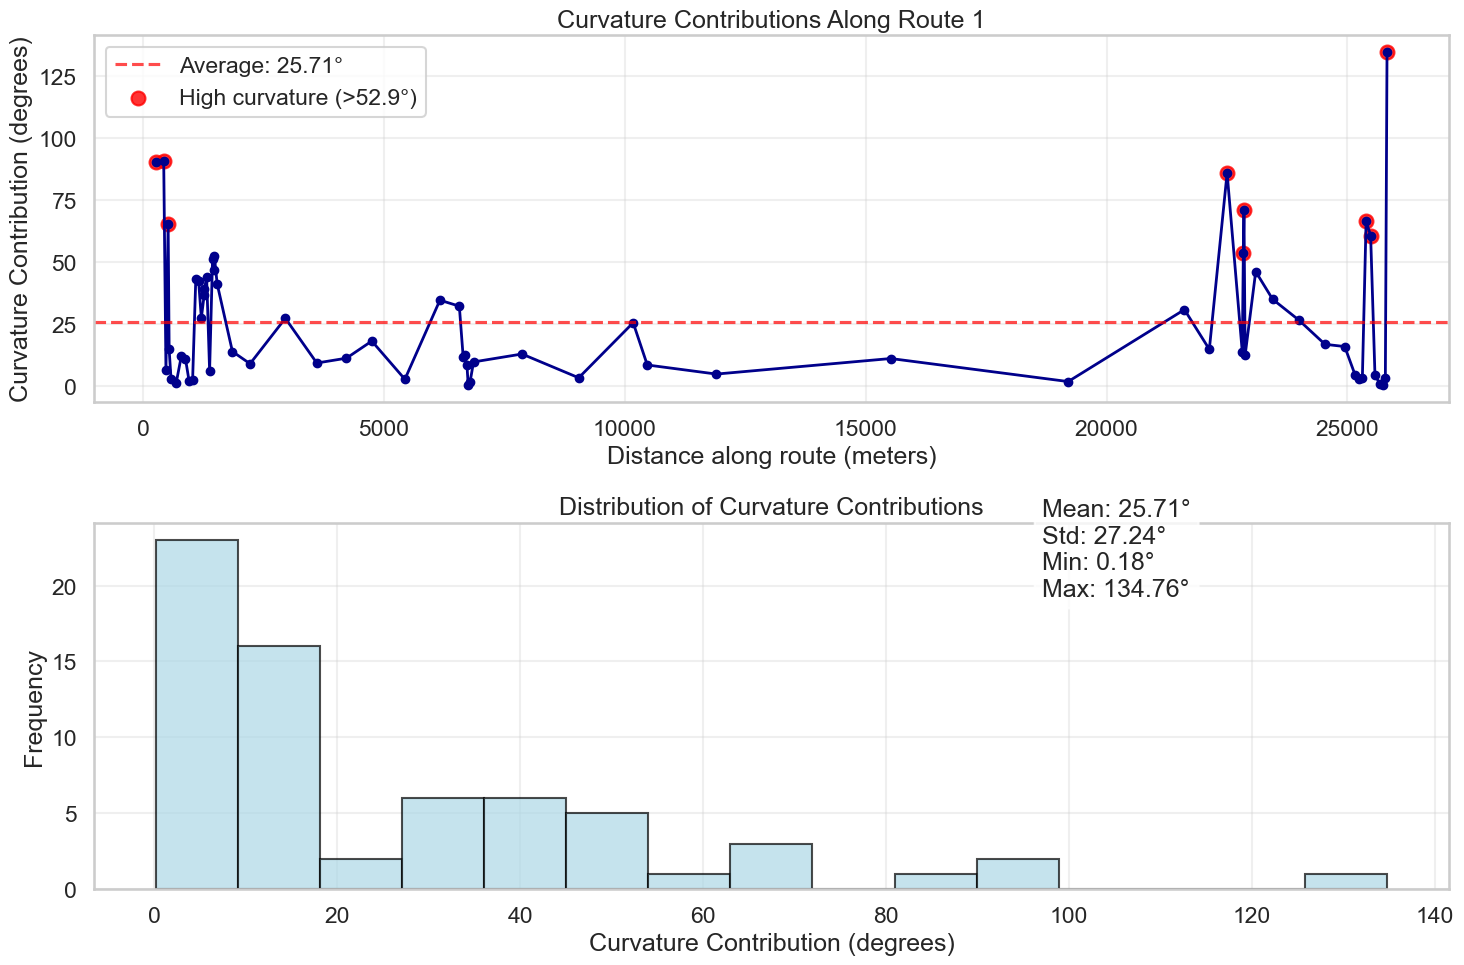


Route 1 Summary:
Total distance: 25838.6 meters
Number of segments: 66
Average curvature: 25.71° ± 27.24°
Curvature range: 0.18° to 134.76°
High curvature segments: 9 (13.6%)


In [121]:
# Create a complementary plot showing curvature along route distance
import matplotlib.pyplot as plt

# Calculate cumulative distances along the route
cumulative_distances = [0]
for i in range(len(route_nodes) - 1):
    edge_length = Gc[route_nodes[i]][route_nodes[i+1]][0]["length"]
    cumulative_distances.append(cumulative_distances[-1] + edge_length)

# Create the plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Plot 1: Curvature contributions along route distance
segment_distances = []
for i in range(len(contributions)):
    # Distance at the middle point of each segment
    mid_distance = (cumulative_distances[i] + cumulative_distances[i+1] + cumulative_distances[i+2]) / 3
    segment_distances.append(mid_distance)

ax1.plot(segment_distances, contributions, 'o-', markersize=6, linewidth=2, color='darkblue')
ax1.set_xlabel('Distance along route (meters)')
ax1.set_ylabel('Curvature Contribution (degrees)')
ax1.set_title(f'Curvature Contributions Along Route {route_idx + 1}')
ax1.grid(True, alpha=0.3)

# Add horizontal line for average
avg_contrib = np.mean(contributions)
ax1.axhline(y=avg_contrib, color='red', linestyle='--', alpha=0.7, 
           label=f'Average: {avg_contrib:.2f}°')
ax1.legend()

# Highlight high curvature segments
high_curvature_threshold = avg_contrib + np.std(contributions)
high_curv_indices = [i for i, c in enumerate(contributions) if c > high_curvature_threshold]
if high_curv_indices:
    high_curv_distances = [segment_distances[i] for i in high_curv_indices]
    high_curv_values = [contributions[i] for i in high_curv_indices]
    ax1.scatter(high_curv_distances, high_curv_values, color='red', s=100, 
               alpha=0.8, label=f'High curvature (>{high_curvature_threshold:.1f}°)')
    ax1.legend()

# Plot 2: Histogram of curvature contributions
ax2.hist(contributions, bins=15, color='lightblue', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Curvature Contribution (degrees)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Curvature Contributions')
ax2.grid(True, alpha=0.3)

# Add statistics text
stats_text = f'Mean: {np.mean(contributions):.2f}°\nStd: {np.std(contributions):.2f}°\nMin: {min(contributions):.2f}°\nMax: {max(contributions):.2f}°'
ax2.text(0.7, 0.8, stats_text, transform=ax2.transAxes, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nRoute {route_idx + 1} Summary:")
print(f"Total distance: {cumulative_distances[-1]:.1f} meters")
print(f"Number of segments: {len(contributions)}")
print(f"Average curvature: {np.mean(contributions):.2f}° ± {np.std(contributions):.2f}°")
print(f"Curvature range: {min(contributions):.2f}° to {max(contributions):.2f}°")
print(f"High curvature segments: {len(high_curv_indices)} ({len(high_curv_indices)/len(contributions)*100:.1f}%)")



FINAL SUMMARY: Angle-based Curvature Analysis

Total segments analyzed: 9171
Overall average curvature contribution: 23.15°
Overall standard deviation: 26.12°

Route-level statistics:
Average curvature per route: 24.79° ± 4.98°
Most curved route: 44.65°
Least curved route: 17.24°


C:\Users\arche\AppData\Local\Temp\ipykernel_23428\2740918417.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax4.boxplot(data_to_plot, labels=[f'R{i+1}' for i in range(len(data_to_plot))])


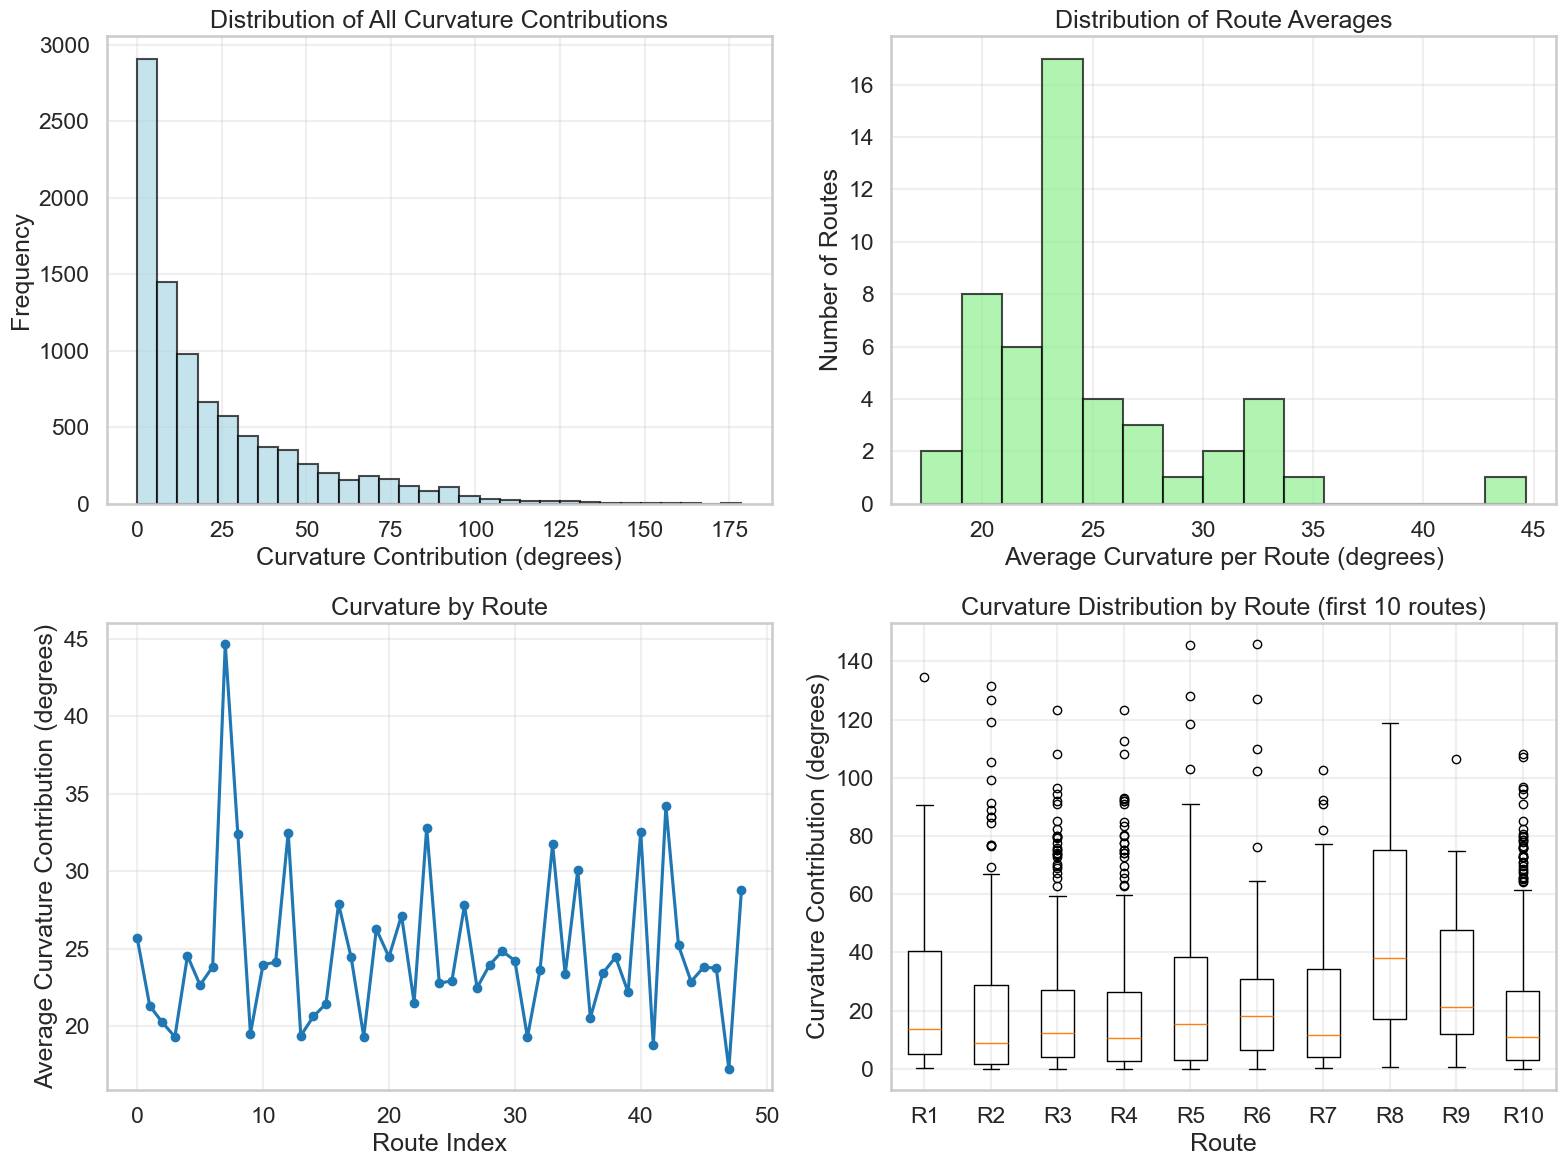


✅ SUCCESS: The new angle-based approach provides interpretable results!
   - Straight segments contribute ~0° (as expected)
   - Curved segments contribute higher values
   - No infinite values or numerical issues
   - Results are directly comparable across routes


In [122]:
# Final summary and visualization
print("\n" + "="*80)
print("FINAL SUMMARY: Angle-based Curvature Analysis")
print("="*80)

# Overall statistics
all_contributions = [contrib for route_contribs in route_curvature_details for contrib in route_contribs]
print(f"\nTotal segments analyzed: {len(all_contributions)}")
print(f"Overall average curvature contribution: {np.mean(all_contributions):.2f}°")
print(f"Overall standard deviation: {np.std(all_contributions):.2f}°")

# Route-level statistics
print(f"\nRoute-level statistics:")
print(f"Average curvature per route: {np.mean(route_curvature_means):.2f}° ± {np.std(route_curvature_means):.2f}°")
print(f"Most curved route: {max(route_curvature_means):.2f}°")
print(f"Least curved route: {min(route_curvature_means):.2f}°")

# Create final visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribution of all contributions
ax1.hist(all_contributions, bins=30, color='lightblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Curvature Contribution (degrees)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of All Curvature Contributions')
ax1.grid(True, alpha=0.3)

# 2. Route-level average contributions
ax2.hist(route_curvature_means, bins=15, color='lightgreen', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Average Curvature per Route (degrees)')
ax2.set_ylabel('Number of Routes')
ax2.set_title('Distribution of Route Averages')
ax2.grid(True, alpha=0.3)

# 3. Route averages over route index
ax3.plot(range(len(route_curvature_means)), route_curvature_means, 'o-', markersize=6)
ax3.set_xlabel('Route Index')
ax3.set_ylabel('Average Curvature Contribution (degrees)')
ax3.set_title('Curvature by Route')
ax3.grid(True, alpha=0.3)

# 4. Box plot comparison
data_to_plot = [route_curvature_details[i] for i in range(min(10, len(route_curvature_details)))]
ax4.boxplot(data_to_plot, labels=[f'R{i+1}' for i in range(len(data_to_plot))])
ax4.set_xlabel('Route')
ax4.set_ylabel('Curvature Contribution (degrees)')
ax4.set_title('Curvature Distribution by Route (first 10 routes)')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ SUCCESS: The new angle-based approach provides interpretable results!")
print(f"   - Straight segments contribute ~0° (as expected)")
print(f"   - Curved segments contribute higher values")
print(f"   - No infinite values or numerical issues")
print(f"   - Results are directly comparable across routes")
